<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Intrinsic Validation 4 - Numerical Method
---
This notebook isolates numerical Earth-profile convergence for the Standard Model, NSI and $3+1$ sterile-neutrino extension.

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Standard-Model) | **Standard Model** |
| [4](#4.-NSI) | **NSI** |
| [5](#5.-31-Sterile-Neutrino) | **$3+1$ Sterile Neutrino** |
| [6](#6.-Summary) | **Summary** |


## 0. Theoretical Framework
---
The numerical evolutor replaces a varying matter profile by $N_{\rm step}$ midpoint-sampled constant-Hamiltonian segments,

$$S_{\rm num}=\prod_{j=N-1}^{0}\exp[-iH(x_{j+1/2})\Delta x_j].$$

Each exponential is unitary for a Hermitian Hamiltonian. The approximation is entirely due to discretizing the profile, so convergence is tested against the largest step count. The same Earth trajectory and grids are applied independently to the Standard Model, NSI and $3+1$ sterile Hamiltonians. Relative errors exclude reference probabilities below $10^{-3}$.

**References**

No external references are cited in this notebook.


## 1. Libraries




In [1]:
from __future__ import annotations
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import ABSOLUTE_THRESHOLD, save_and_show, to_numpy, validation_metrics, validation_summary_plot
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.util.context import RuntimeContext


## 2. Paths and Configuration




### 2.1 Paths

`load_notebook_config()` resolves the package directory and the common Torch, NumPy and plotting configuration. Generated figures are written under `validation/intrinsic/`.


In [2]:
config = load_notebook_config()
DEVICE, DTYPE = config.device, config.dtype
context = RuntimeContext.resolve(DEVICE, DTYPE)
OUTPUT_DIR = config.output_dir('validation', 'intrinsic')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {context.device}   dtype: {context.dtype}')


Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\validation\intrinsic
Device      : cuda:0   dtype: torch.float64


### 2.2 Configuration

The three model sections use identical Earth, energy, angular, depth, precision and error-threshold settings. Only the oscillation/BSM model is changed.


In [3]:
SM_PRESET = '_SM_NUFIT52_NO'
NSI_PRESET = 'nsi_globalfit_esteban2018'
STERILE_PRESET = 'sterile_3p1_bestfit_giunti2017'
MODEL_LABELS = {'sm': 'Standard Model', 'nsi': 'NSI', 'sterile': '3+1 sterile'}
DEPTH_M, N_EARTH_STEPS = 1000.0, 400
LEGACY_PRECISION = False
ABSOLUTE_THRESHOLD = 1e-3
earth = EarthProfile(params=EarthParameters(density_provider='prem', profile_perturbative_name='even_power', profile_perturbative_kwargs={'density_file': str(config.earth_density_file), 'tabulated_density': False,"include_neutron": True,}), context=context)
def model_oscillation(model, runtime_context=context):
    if model == 'sm':
        return PropagationConfig.oscillation_parameters_from_preset(SM_PRESET, context=runtime_context, antinu=False)
    if model == 'nsi':
        return PropagationConfig.oscillation_parameters_from_preset(SM_PRESET, context=runtime_context, antinu=False, NSI_extension=NSI_PRESET)
    if model == 'sterile':
        return PropagationConfig.oscillation_parameters_from_preset(STERILE_PRESET, context=runtime_context, antinu=False)
    raise ValueError(f'Unknown model: {model!r}')
def select_model(model):
    global oscillation, N_FLAVOURS, CDTYPE, BASIS, FLAVOUR_LABELS, FLAVOUR_COLOURS
    oscillation = model_oscillation(model)
    N_FLAVOURS = int(oscillation.pmns.n_flavours)
    CDTYPE = torch.complex128 if context.dtype == torch.float64 else torch.complex64
    BASIS = torch.eye(N_FLAVOURS, device=context.device, dtype=CDTYPE)
    FLAVOUR_LABELS = [r'$\nu_e$', r'$\nu_\mu$', r'$\nu_\tau$'] + ([r'$\nu_s$'] if N_FLAVOURS == 4 else [])
    FLAVOUR_COLOURS = tuple(f'C{i}' for i in range(N_FLAVOURS))
    print(f'{MODEL_LABELS[model]}: {N_FLAVOURS} flavours, preset={oscillation.preset_name}')


### 2.3 Local Helpers

The helpers below centralize the repeated scans and plotting logic while each model section explicitly selects its own oscillation parameters and flavour dimension.


In [4]:
E_STUDY = torch.logspace(np.log10(100.0), np.log10(2e4), 60, device=context.device, dtype=context.dtype)
ETA_STUDY = torch.linspace(0.05, 1.50, 60, device=context.device, dtype=context.dtype)
STEP_COUNTS = np.unique(np.rint(np.geomspace(2, 2000, 10)).astype(int))
def numerical_two_scans(nsteps):
    state = BASIS[0]
    energy_scan = earth_probability_state(state, earth, oscillation, E_STUDY[:,None], torch.tensor(0.60, device=context.device, dtype=context.dtype), DEPTH_M, method='numerical', massbasis=False, nsteps=int(nsteps), context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_STUDY.numel(),N_FLAVOURS)
    angle_scan = torch.stack([earth_probability_state(state, earth, oscillation, torch.tensor(5000.0, device=context.device, dtype=context.dtype), eta, DEPTH_M, method='numerical', massbasis=False, nsteps=int(nsteps), context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION) for eta in ETA_STUDY])
    return energy_scan, angle_scan
def numerical_convergence_study(model, filename_prefix):
    select_model(model)
    results = {int(n): numerical_two_scans(int(n)) for n in STEP_COUNTS}
    reference = results[int(STEP_COUNTS[-1])]
    rows = []
    for nsteps, tested in results.items():
        row, _, _ = validation_metrics(f'{nsteps} steps', torch.cat(reference), torch.cat(tested), reference_label='2000 steps', tested_label=f'{nsteps} steps', absolute_threshold=ABSOLUTE_THRESHOLD)
        row['nsteps'] = nsteps; rows.append(row)
    table = pd.DataFrame(rows).set_index('nsteps')
    display(table.style.format({column: '{:.3e}' for column in table.select_dtypes(include='number').columns}))
    fig, axes = plt.subplots(3,2,figsize=(14,11),sharex='col')
    for column, (x, index, xlabel) in enumerate([(E_STUDY,0,'E [MeV]'),(ETA_STUDY,1,'eta [rad]')]):
        reference_scan = reference[index]
        for nsteps, pair in results.items():
            scan = pair[index]; alpha = 1.0 if nsteps == STEP_COUNTS[-1] else 0.55
            axes[0,column].plot(to_numpy(x),to_numpy(scan[:,0]),label=f'{nsteps} steps',alpha=alpha)
            _, absolute, relative = validation_metrics(str(nsteps), reference_scan, scan, absolute_threshold=ABSOLUTE_THRESHOLD)
            axes[1,column].plot(to_numpy(x),to_numpy(absolute.amax(dim=-1)),alpha=alpha)
            axes[2,column].plot(to_numpy(x),to_numpy(relative.amax(dim=-1)),alpha=alpha)
        axes[1,column].set_yscale('log'); axes[2,column].set_yscale('log'); axes[2,column].set_xlabel(xlabel); axes[0,column].grid(alpha=.25)
    for ax,label in zip(axes[:,0],[r'$P_{ee}$','Maximum absolute error','Maximum relative error']): ax.set_ylabel(label)
    for ax in axes.flat: ax.grid(alpha=.25)
    axes[0,1].legend(fontsize=6,ncol=2)
    fig.suptitle(f'{MODEL_LABELS[model]}: numerical Earth convergence'); fig.tight_layout()
    save_and_show(f'{filename_prefix}_convergence.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)
    E_point = torch.tensor(10000.0, device=context.device, dtype=context.dtype); eta_point = torch.tensor(torch.pi/4, device=context.device, dtype=context.dtype)
    point = {int(n): earth_probability_state(BASIS[0], earth, oscillation, E_point, eta_point, DEPTH_M, method='numerical', massbasis=False, nsteps=int(n), context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION) for n in STEP_COUNTS}
    point_reference = point[int(STEP_COUNTS[-1])]; abs_values=[]; rel_values=[]
    for nsteps in STEP_COUNTS:
        _, absolute, relative = validation_metrics(str(int(nsteps)), point_reference, point[int(nsteps)], absolute_threshold=ABSOLUTE_THRESHOLD)
        abs_values.append(absolute.max().item()); rel_values.append(relative.max().item())
    fig, axes = plt.subplots(1,2,figsize=(13.5,4.8),sharex=True)
    axes[0].plot(STEP_COUNTS,np.maximum(abs_values,1e-18),marker='o'); axes[1].plot(STEP_COUNTS,np.maximum(rel_values,1e-18),marker='o')
    for ax,ylabel in zip(axes,('Maximum absolute error','Maximum relative error')):
        ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel(r'$n_{\rm steps}$'); ax.set_ylabel(ylabel); ax.grid(alpha=.25)
    fig.suptitle(rf'{MODEL_LABELS[model]}: $E=10\,000\,\mathrm{{MeV}}$, $\eta=\pi/4$'); fig.tight_layout()
    save_and_show(f'{filename_prefix}_point.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)
    return table


## 3. Standard Model

This section studies coherent $\nu_e$ propagation through the PREM/even-power Earth profile for the Standard Model Hamiltonian. Ten approximately logarithmic step counts from 2 to 2000 are compared with the 2000-step result.

**Expected results:**<br>
- Errors should decrease overall as the midpoint discretization is refined; the final row is zero by construction.


Standard Model: 3 flavours, preset=_SM_NUFIT52_NO


,case,max_abs,mean_abs,max_rel,mean_rel,normalization_2000 steps,normalization_2 steps,relative_points,absolute_threshold,normalization_4 steps,normalization_9 steps,normalization_20 steps,normalization_43 steps,normalization_93 steps,normalization_200 steps,normalization_431 steps,normalization_928 steps
nsteps,,,,,,,,,,,,,,,,,
2,2 steps,6.732e-01,6.397e-02,1.854e+02,1.085e+00,6.399e-13,3.262e-13,3.540e+02,1.000e-03,nan,nan,nan,nan,nan,nan,nan,nan
4,4 steps,6.473e-01,2.801e-02,2.713e+01,2.595e-01,6.399e-13,nan,3.540e+02,1.000e-03,3.584e-13,nan,nan,nan,nan,nan,nan,nan
9,9 steps,2.089e-01,1.577e-02,7.412e+01,3.740e-01,6.399e-13,nan,3.540e+02,1.000e-03,nan,8.149e-14,nan,nan,nan,nan,nan,nan
20,20 steps,1.598e-01,8.685e-03,5.978e+00,7.643e-02,6.399e-13,nan,3.540e+02,1.000e-03,nan,nan,1.636e-13,nan,nan,nan,nan,nan
43,43 steps,7.496e-02,3.256e-03,8.152e-01,2.261e-02,6.399e-13,nan,3.540e+02,1.000e-03,nan,nan,nan,1.734e-13,nan,nan,nan,nan
93,93 steps,3.344e-02,1.646e-03,2.527e-01,1.040e-02,6.399e-13,nan,3.540e+02,1.000e-03,nan,nan,nan,nan,9.437e-14,nan,nan,nan
200,200 steps,1.356e-02,6.722e-04,1.624e-01,4.225e-03,6.399e-13,nan,3.540e+02,1.000e-03,nan,nan,nan,nan,nan,7.150e-14,nan,nan
431,431 steps,5.540e-03,2.357e-04,1.049e-01,1.830e-03,6.399e-13,nan,3.540e+02,1.000e-03,nan,nan,nan,nan,nan,nan,8.726e-14,nan
928,928 steps,3.236e-03,1.646e-04,5.371e-02,1.327e-03,6.399e-13,nan,3.540e+02,1.000e-03,nan,nan,nan,nan,nan,nan,nan,1.729e-13


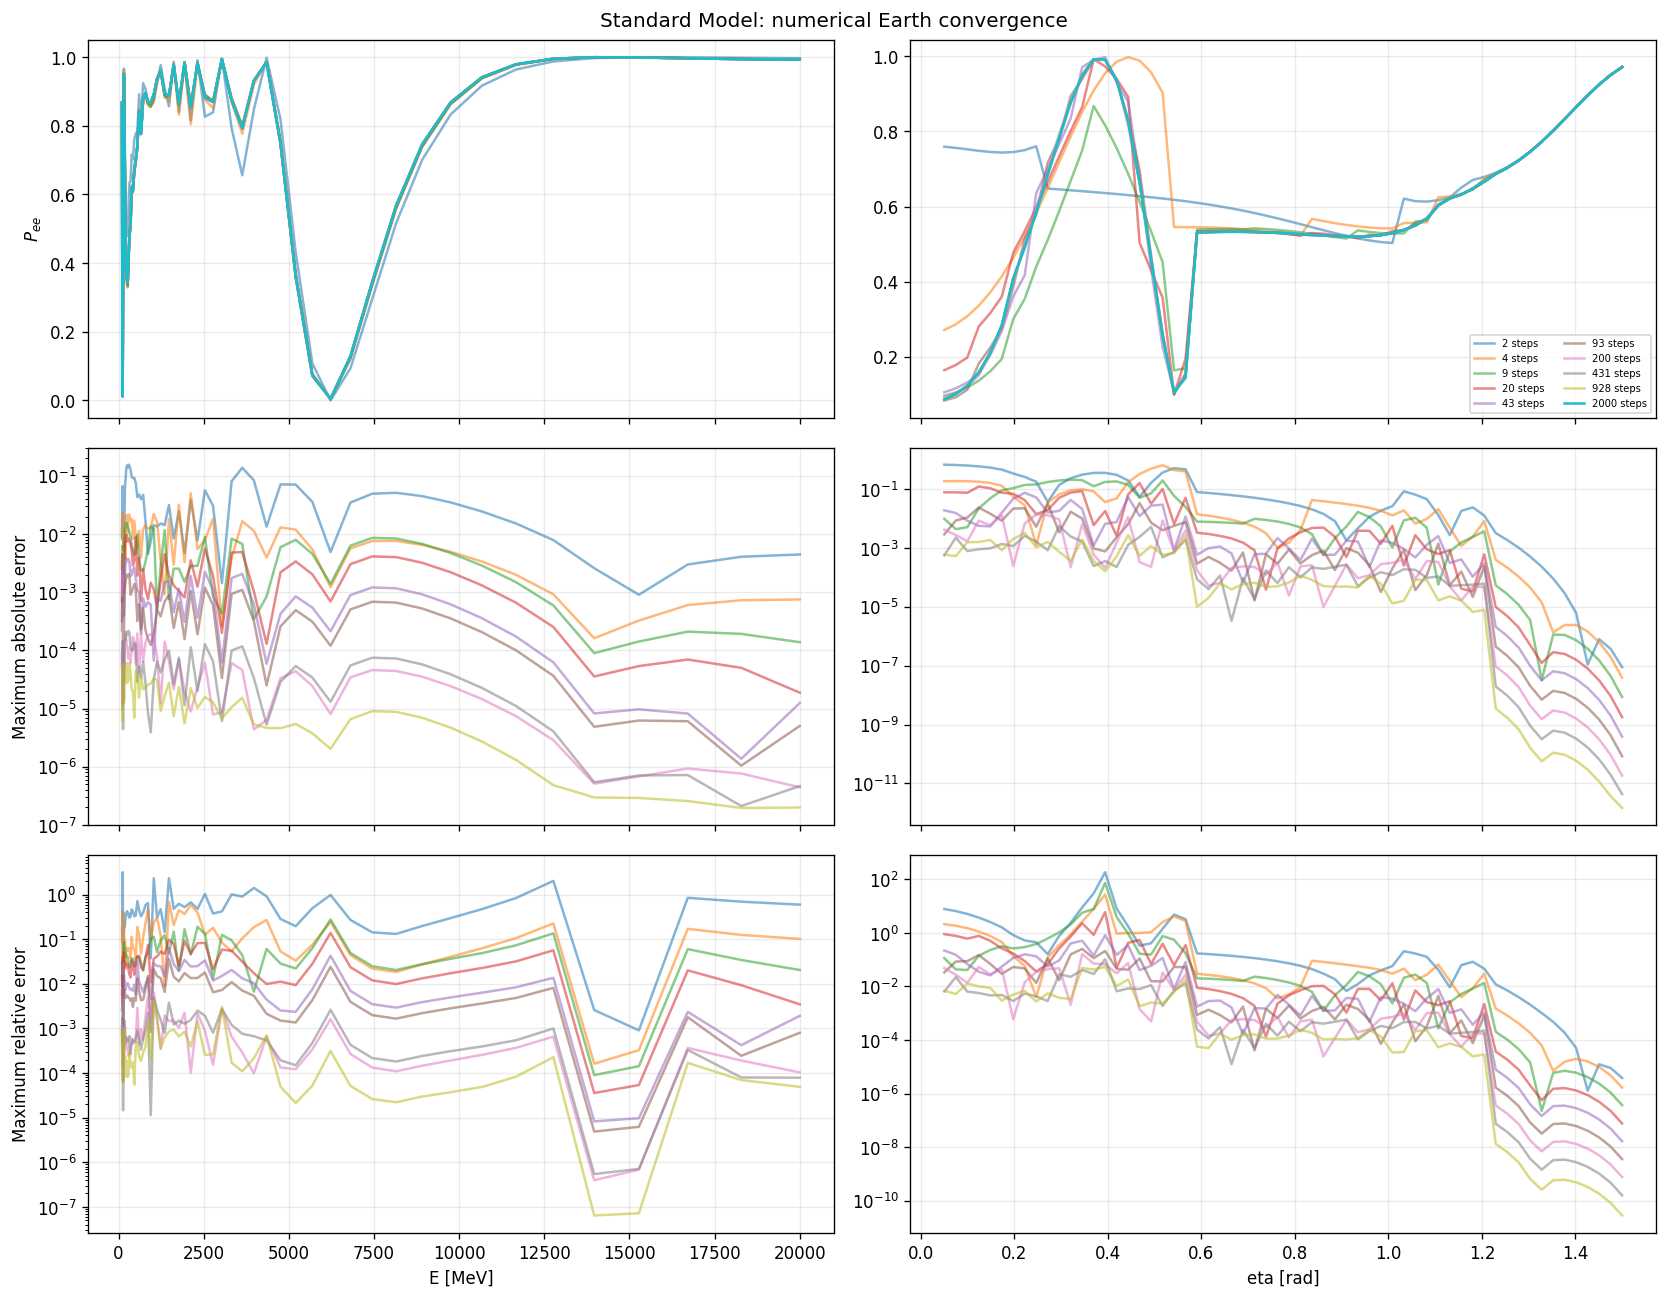

v:\output\validation\intrinsic\intrinsic4_sm_fig3_convergence.png


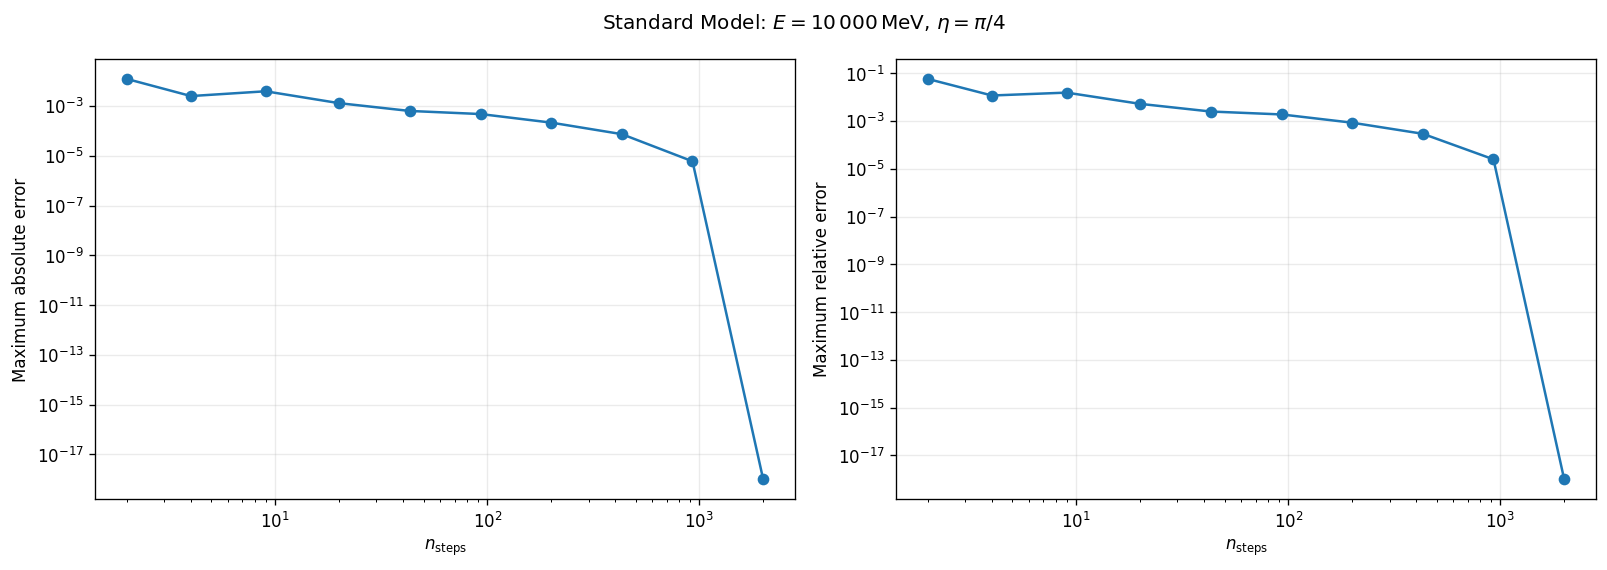

v:\output\validation\intrinsic\intrinsic4_sm_fig3_point.png


In [5]:
sm_numerical_table = numerical_convergence_study('sm', 'intrinsic4_sm_fig3')


## 4. NSI

This section studies coherent $\nu_e$ propagation through the PREM/even-power Earth profile for the NSI Hamiltonian. Ten approximately logarithmic step counts from 2 to 2000 are compared with the 2000-step result.

**Expected results:**<br>
- Errors should decrease overall as the midpoint discretization is refined; the final row is zero by construction.


NSI: 3 flavours, preset=_SM_NUFIT52_NO


,case,max_abs,mean_abs,max_rel,mean_rel,normalization_2000 steps,normalization_2 steps,relative_points,absolute_threshold,normalization_4 steps,normalization_9 steps,normalization_20 steps,normalization_43 steps,normalization_93 steps,normalization_200 steps,normalization_431 steps,normalization_928 steps
nsteps,,,,,,,,,,,,,,,,,
2,2 steps,8.699e-01,5.805e-02,1.469e+02,1.292e+00,6.164e-13,3.701e-13,3.570e+02,1.000e-03,nan,nan,nan,nan,nan,nan,nan,nan
4,4 steps,6.881e-01,2.101e-02,4.288e+01,5.270e-01,6.164e-13,nan,3.570e+02,1.000e-03,1.967e-13,nan,nan,nan,nan,nan,nan,nan
9,9 steps,3.905e-01,1.505e-02,6.650e+00,1.185e-01,6.164e-13,nan,3.570e+02,1.000e-03,nan,1.781e-13,nan,nan,nan,nan,nan,nan
20,20 steps,8.656e-02,6.696e-03,9.403e+00,1.318e-01,6.164e-13,nan,3.570e+02,1.000e-03,nan,nan,5.962e-14,nan,nan,nan,nan,nan
43,43 steps,6.398e-02,2.593e-03,1.644e+00,3.175e-02,6.164e-13,nan,3.570e+02,1.000e-03,nan,nan,nan,8.971e-14,nan,nan,nan,nan
93,93 steps,2.718e-02,1.347e-03,4.392e-01,1.657e-02,6.164e-13,nan,3.570e+02,1.000e-03,nan,nan,nan,nan,4.796e-14,nan,nan,nan
200,200 steps,1.161e-02,5.188e-04,3.774e-01,6.204e-03,6.164e-13,nan,3.570e+02,1.000e-03,nan,nan,nan,nan,nan,7.105e-14,nan,nan
431,431 steps,4.470e-03,1.842e-04,1.224e-01,2.367e-03,6.164e-13,nan,3.570e+02,1.000e-03,nan,nan,nan,nan,nan,nan,8.504e-14,nan
928,928 steps,4.966e-03,1.474e-04,5.914e-02,1.688e-03,6.164e-13,nan,3.570e+02,1.000e-03,nan,nan,nan,nan,nan,nan,nan,1.248e-13


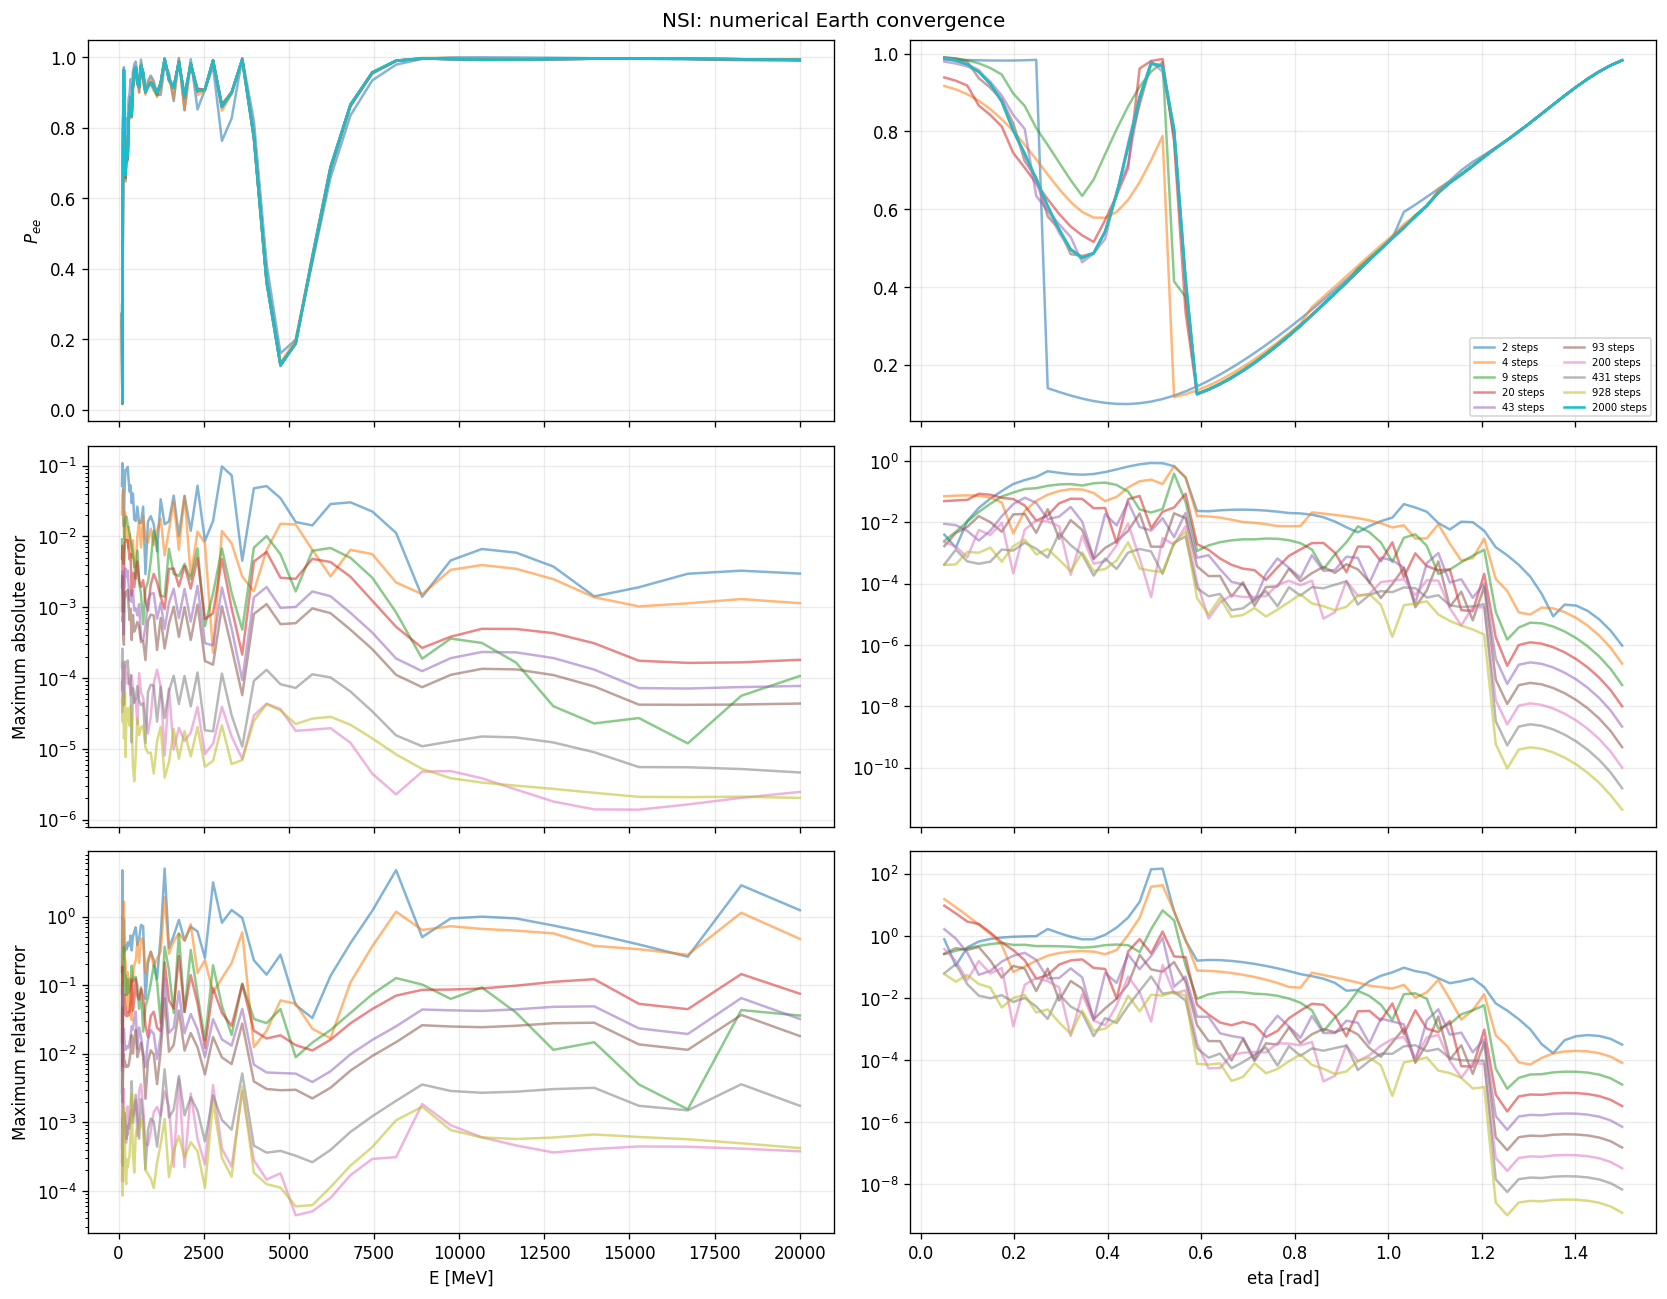

v:\output\validation\intrinsic\intrinsic4_nsi_fig4_convergence.png


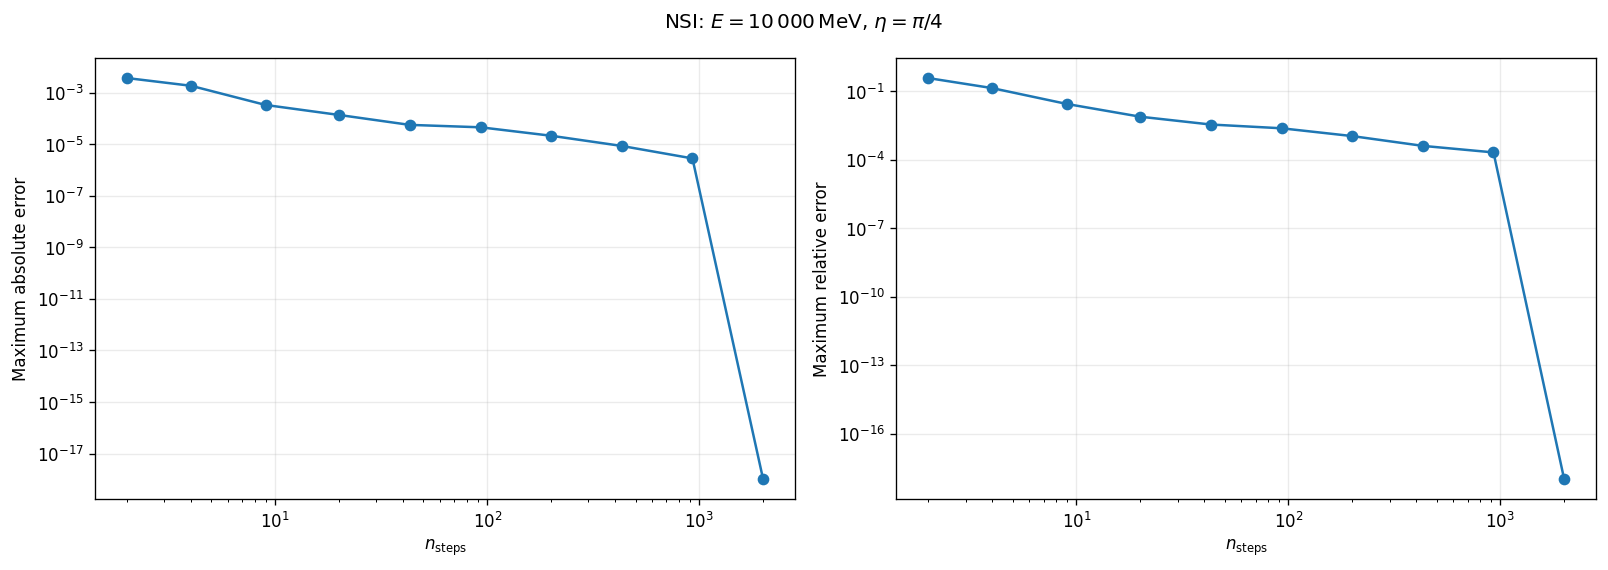

v:\output\validation\intrinsic\intrinsic4_nsi_fig4_point.png


In [6]:
nsi_numerical_table = numerical_convergence_study('nsi', 'intrinsic4_nsi_fig4')


## 5. $3+1$ Sterile Neutrino

This section studies coherent $\nu_e$ propagation through the PREM/even-power Earth profile for the $3+1$ Sterile Neutrino Hamiltonian. Ten approximately logarithmic step counts from 2 to 2000 are compared with the 2000-step result.

**Expected results:**<br>
- Errors should decrease overall as the midpoint discretization is refined; the final row is zero by construction.


3+1 sterile: 4 flavours, preset=sterile_3p1_bestfit_giunti2017


,case,max_abs,mean_abs,max_rel,mean_rel,normalization_2000 steps,normalization_2 steps,relative_points,absolute_threshold,normalization_4 steps,normalization_9 steps,normalization_20 steps,normalization_43 steps,normalization_93 steps,normalization_200 steps,normalization_431 steps,normalization_928 steps
nsteps,,,,,,,,,,,,,,,,,
2,2 steps,6.581e-01,4.773e-02,6.669e+01,7.335e-01,4.803e-11,1.547e-10,4.630e+02,1.000e-03,nan,nan,nan,nan,nan,nan,nan,nan
4,4 steps,6.160e-01,2.167e-02,1.483e+01,2.064e-01,4.803e-11,nan,4.630e+02,1.000e-03,1.223e-10,nan,nan,nan,nan,nan,nan,nan
9,9 steps,1.945e-01,1.201e-02,2.449e+01,2.207e-01,4.803e-11,nan,4.630e+02,1.000e-03,nan,1.567e-10,nan,nan,nan,nan,nan,nan
20,20 steps,1.566e-01,6.673e-03,3.267e+00,5.777e-02,4.803e-11,nan,4.630e+02,1.000e-03,nan,nan,8.488e-11,nan,nan,nan,nan,nan
43,43 steps,7.550e-02,2.470e-03,9.194e-01,2.101e-02,4.803e-11,nan,4.630e+02,1.000e-03,nan,nan,nan,1.062e-10,nan,nan,nan,nan
93,93 steps,3.332e-02,1.252e-03,3.319e-01,9.452e-03,4.803e-11,nan,4.630e+02,1.000e-03,nan,nan,nan,nan,1.613e-10,nan,nan,nan
200,200 steps,1.317e-02,5.113e-04,2.120e-01,3.766e-03,4.803e-11,nan,4.630e+02,1.000e-03,nan,nan,nan,nan,nan,5.259e-11,nan,nan
431,431 steps,5.116e-03,1.782e-04,5.499e-02,1.566e-03,4.803e-11,nan,4.630e+02,1.000e-03,nan,nan,nan,nan,nan,nan,5.563e-11,nan
928,928 steps,3.219e-03,1.267e-04,6.249e-02,1.151e-03,4.803e-11,nan,4.630e+02,1.000e-03,nan,nan,nan,nan,nan,nan,nan,7.297e-11


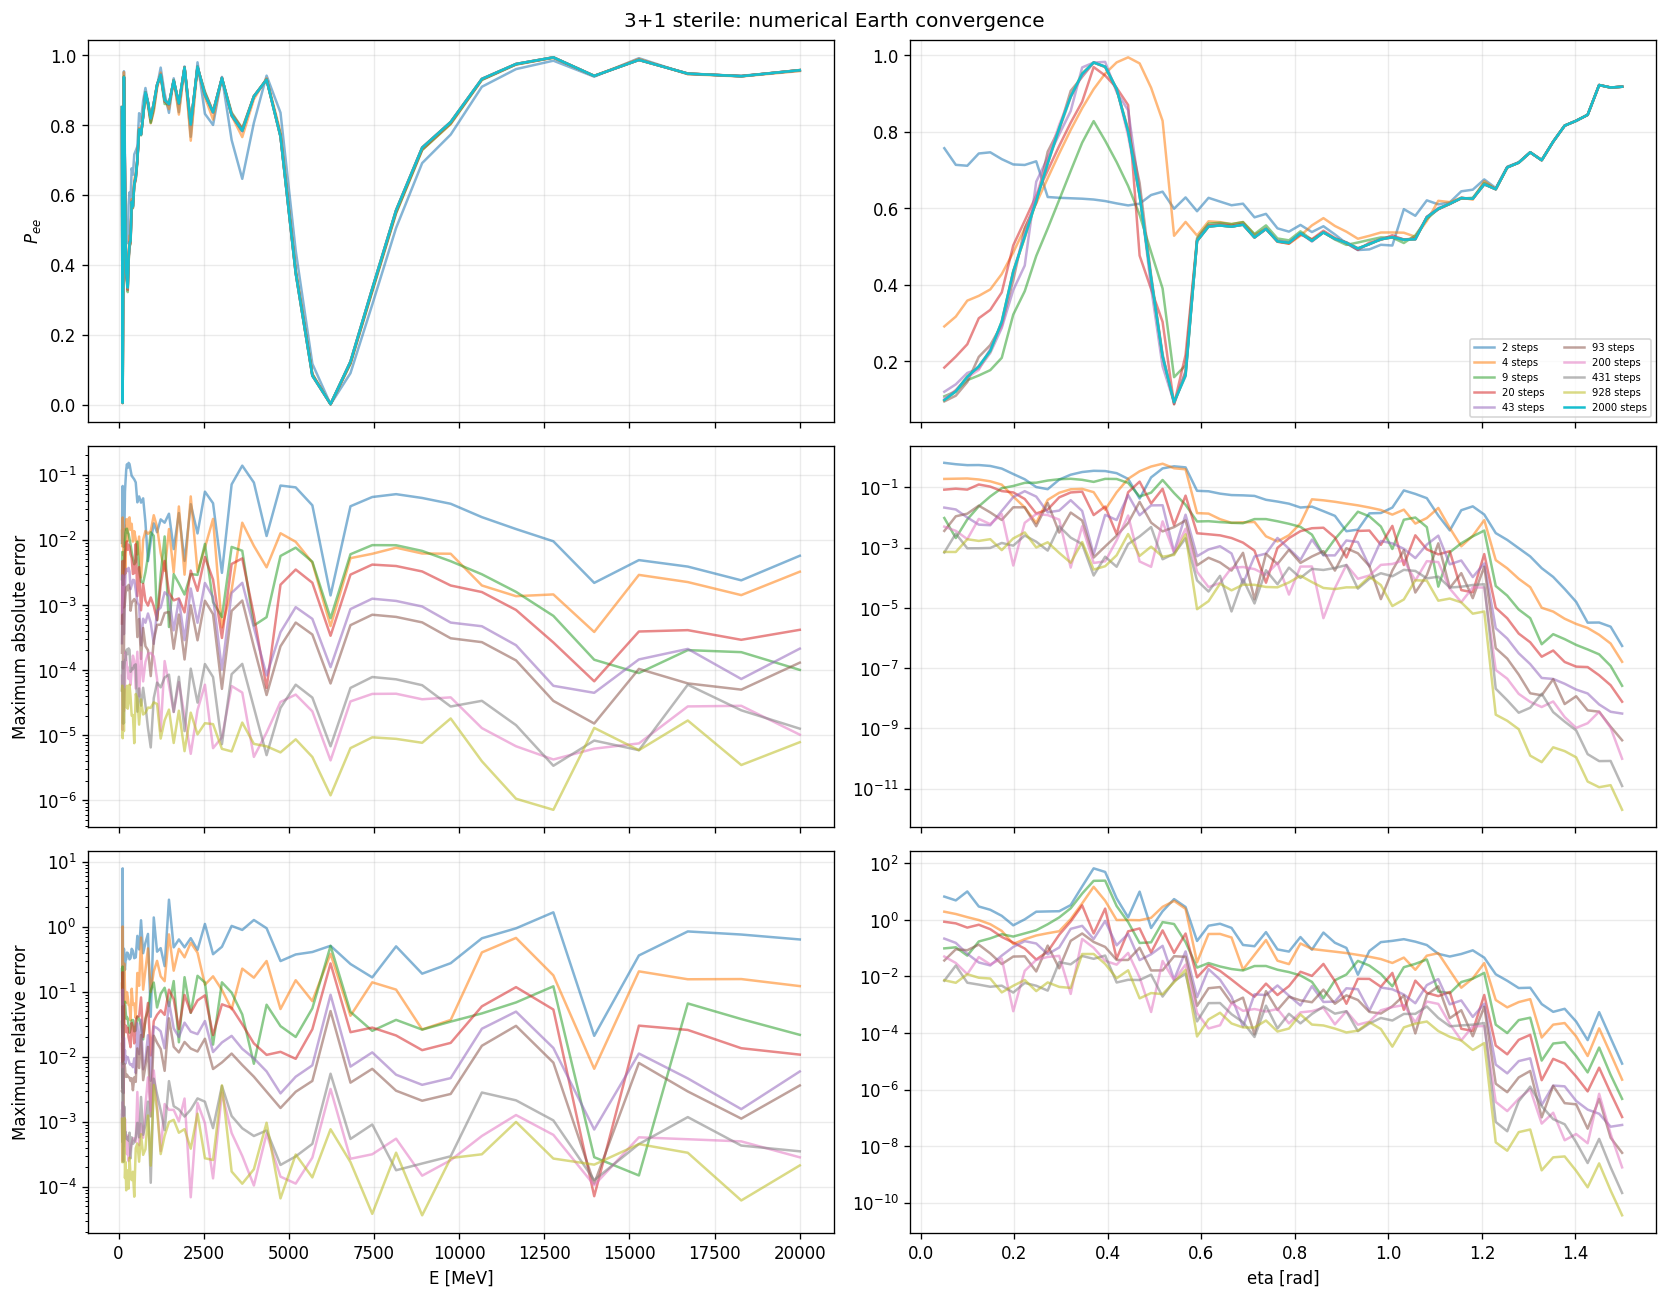

v:\output\validation\intrinsic\intrinsic4_sterile_fig5_convergence.png


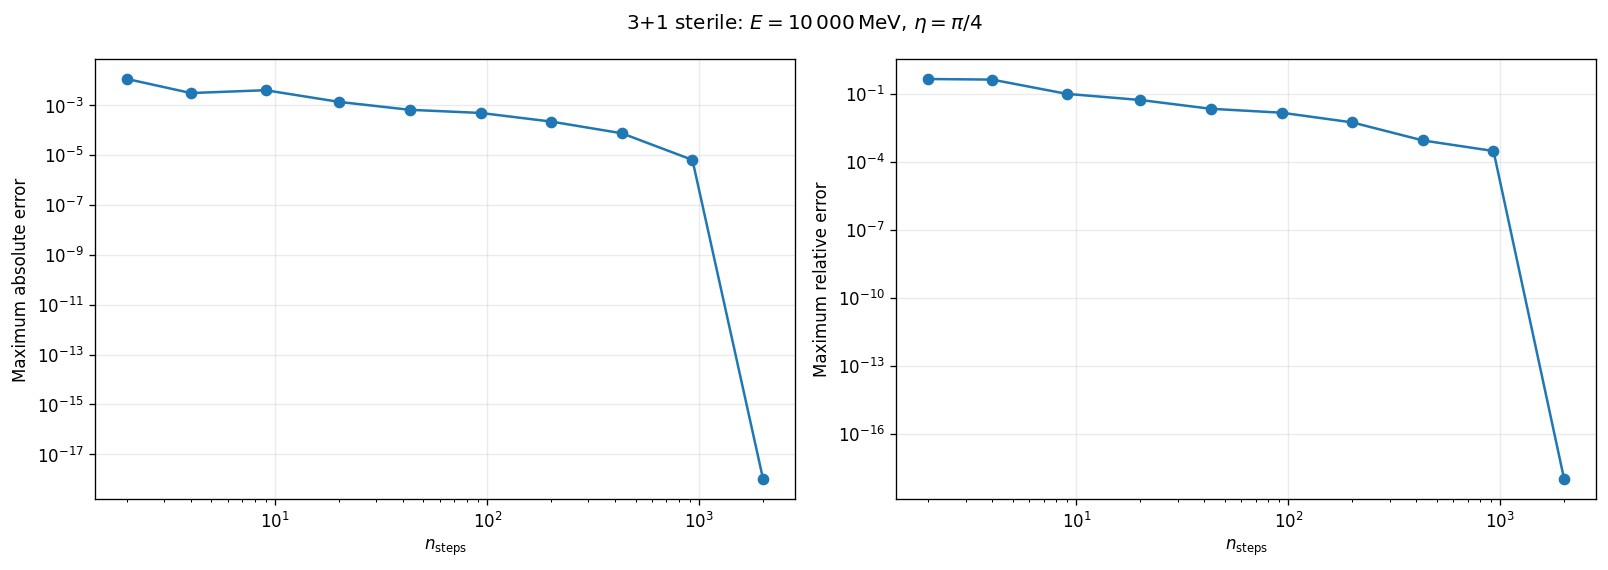

v:\output\validation\intrinsic\intrinsic4_sterile_fig5_point.png


In [7]:
sterile_numerical_table = numerical_convergence_study('sterile', 'intrinsic4_sterile_fig5')


## 6. Summary
The complete convergence results of the three models are combined into one table with model and step-count indices. Because the 2000-step calculation is the reference and therefore has identically zero error, the compact cross-model summary selects the finest independent result, i.e. the penultimate step count.

The $2\times2$ chart compares maximum and mean absolute and thresholded-relative errors for that common step count.

**Expected results:**<br>
- All three models should exhibit decreasing discretization error with increasing `nsteps`.
-  The sterile calculation may be more demanding because it evolves a four-dimensional Hamiltonian and includes the additional fast scale $\Delta m_{41}^2$.


,max_abs,mean_abs,max_rel,mean_rel,normalization_2000 steps,normalization_2 steps,relative_points,absolute_threshold,normalization_4 steps,normalization_9 steps,normalization_20 steps,normalization_43 steps,normalization_93 steps,normalization_200 steps,normalization_431 steps,normalization_928 steps
case,,,,,,,,,,,,,,,,
Standard Model: 928 steps,3.236e-03,1.646e-04,5.371e-02,1.327e-03,6.399e-13,nan,3.540e+02,1.000e-03,nan,nan,nan,nan,nan,nan,nan,1.729e-13
NSI: 928 steps,4.966e-03,1.474e-04,5.914e-02,1.688e-03,6.164e-13,nan,3.570e+02,1.000e-03,nan,nan,nan,nan,nan,nan,nan,1.248e-13
3+1 sterile: 928 steps,3.219e-03,1.267e-04,6.249e-02,1.151e-03,4.803e-11,nan,4.630e+02,1.000e-03,nan,nan,nan,nan,nan,nan,nan,7.297e-11


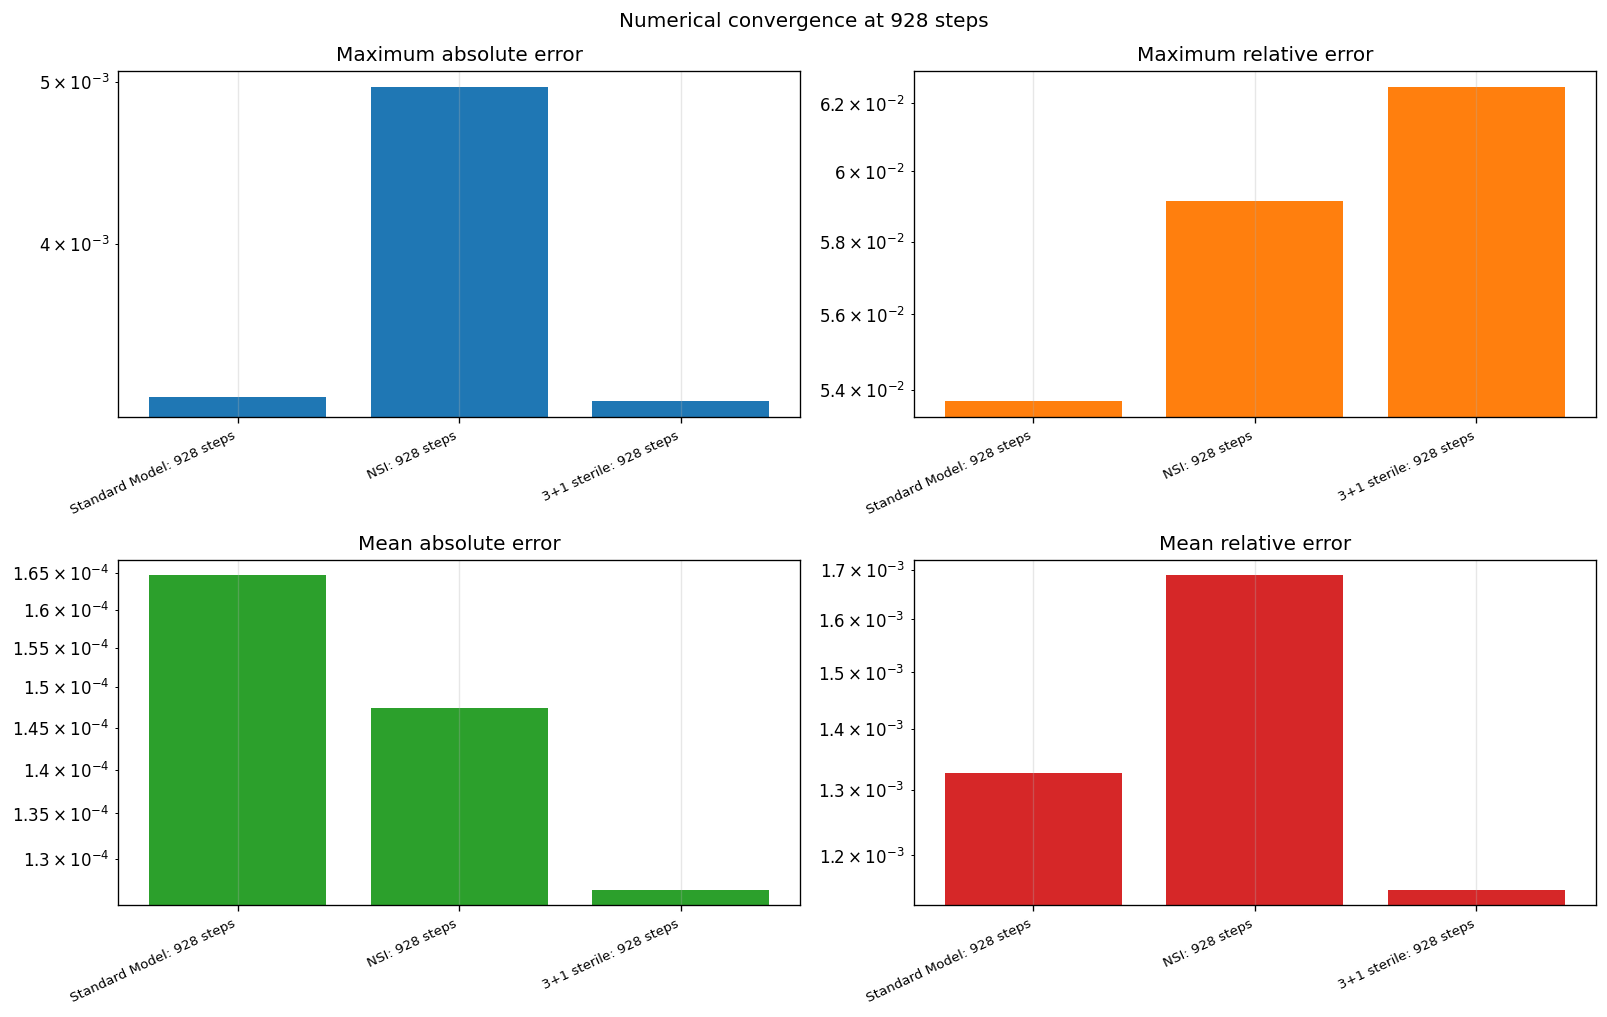

v:\output\validation\intrinsic\intrinsic4_fig6_summary.png


In [8]:
numerical_tables = {'Standard Model': sm_numerical_table, 'NSI': nsi_numerical_table, '3+1 sterile': sterile_numerical_table}
numerical_summary_full = pd.concat(numerical_tables, names=['model','nsteps'])
display(numerical_summary_full.style.format({column: '{:.3e}' for column in numerical_summary_full.select_dtypes(include='number').columns}))
summary_nsteps = int(STEP_COUNTS[-2])
numerical_summary_rows = []
for model_label, table in numerical_tables.items():
    row = table.loc[summary_nsteps].to_dict(); row['case'] = f'{model_label}: {summary_nsteps} steps'; numerical_summary_rows.append(row)
numerical_summary = pd.DataFrame(numerical_summary_rows).set_index('case')
display(numerical_summary.style.format({column: '{:.3e}' for column in numerical_summary.select_dtypes(include='number').columns}))
numerical_summary.to_csv(OUTPUT_DIR / 'validation_intrinsic4_numerical_summary.csv')
validation_summary_plot(numerical_summary_rows, title=f'Numerical convergence at {summary_nsteps} steps', filename='intrinsic4_fig6_summary.png', output_dir=OUTPUT_DIR, show_plots=config.show_plots)
